In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta


In [2]:
# Let's define the basic parameters.
np.random.seed(42)
num_records = 5000

locations = ['Seoul', 'Busan', 'Incheon', 'Daegu', 'Daejeon']
product_categories = ['Smartphones', 'Laptops', 'Tablets', 'Wearables', 'Accessories']
sales_channels = ['Online', 'Retail Store', 'Authorized Reseller']

# Let's generate random dates (data from the last year).
end_date = datetime.now()
start_date = end_date - timedelta(days=365)
random_dates = [start_date + timedelta(days=np.random.randint(0, 365)) for _ in range(num_records)]

# Let's create the dataset (DataFrame).
data = {
    'Transaction-ID': [f"TRX-{10000 + i}" for i in range(num_records)],
    'Date': random_dates,
    'Location': np.random.choice(locations, num_records, p=[0.4, 0.25, 0.15, 0.1, 0.1]),
    'Product_Category': np.random.choice(product_categories, num_records),
    'Sales_Channel': np.random.choice(sales_channels, num_records),
    'Units_Sold': np.random.randint(1, 10, num_records),
    'Unit_Price_USD': np.random.uniform(50, 2000, num_records).round(2),
    'Discount_Applied_Pct': np.random.choice([0, 5, 10, 15, 20], num_records, p=[0.6, 0.15, 0.1, 0.1, 0.05])
}

df = pd.DataFrame(data)

#Let's calculate the total sales amount (this is one of the operations we will perform in SQL).
df['Total_Revenue_USD'] = (df['Units_Sold'] * df['Unit_Price_USD']) * (1 - df['Discount_Applied_Pct'] / 100)
df['Total_Revenue_USD'] = df['Total_Revenue_USD'].round(2)

#Let's sort them chronologically.
df = df.sort_values(by='Date').reset_index(drop=True)

# Let's save the data as a CSV file.
df.to_csv('korea_sales_data_raw.csv', index=False)

print("Congratulations! The 5000-line 'korea_sales_data_raw.csv' file has been successfully created.")
print(df.head())

Congratulations! The 5000-line 'korea_sales_data_raw.csv' file has been successfully created.
  Transaction-ID                       Date Location Product_Category  \
0      TRX-11164 2025-03-08 02:42:49.553295    Seoul        Wearables   
1      TRX-10991 2025-03-08 02:42:49.553295    Busan        Wearables   
2      TRX-13580 2025-03-08 02:42:49.553295    Busan      Accessories   
3      TRX-13071 2025-03-08 02:42:49.553295    Seoul          Laptops   
4      TRX-12010 2025-03-08 02:42:49.553295    Busan          Laptops   

  Sales_Channel  Units_Sold  Unit_Price_USD  Discount_Applied_Pct  \
0  Retail Store           8          487.16                     5   
1  Retail Store           4          378.88                    15   
2  Retail Store           7         1270.47                    10   
3  Retail Store           3         1278.99                     0   
4  Retail Store           4          434.54                     0   

   Total_Revenue_USD  
0            3702.42  
1     

Professional graphic saved as 'korea_regional_revenue.png'.


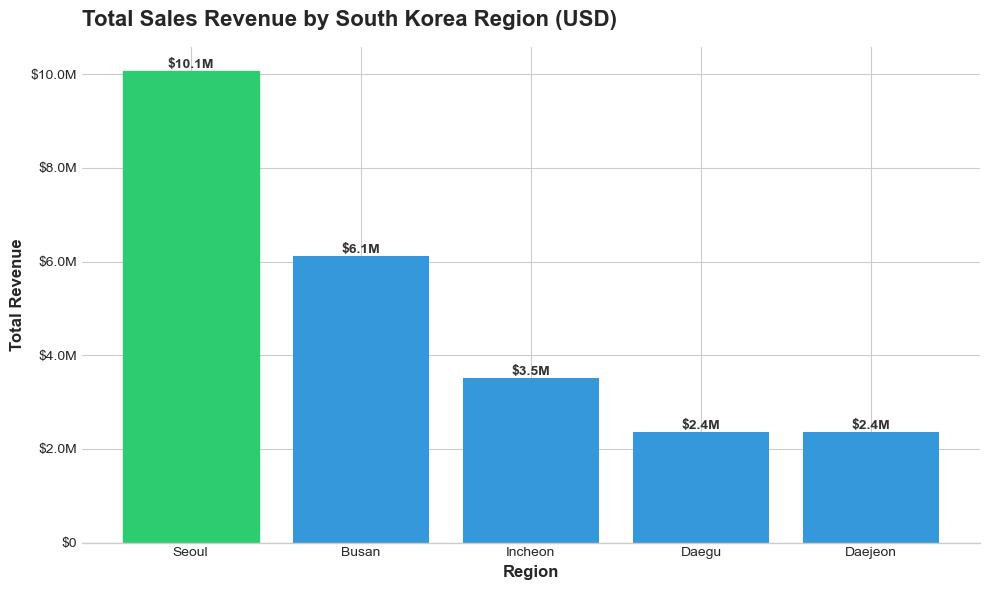

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Calculate total income by region
regional_sales = df.groupby('Location')['Total_Revenue_USD'].sum().sort_values(ascending=False).reset_index()

# matplotlib with professional graphic
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid') 


# draw Bar graphic
bars = plt.bar(regional_sales['Location'], regional_sales['Total_Revenue_USD'], color='#3498db')
bars[0].set_color('#2ecc71') #so the highest sales would be green Seoul

# Critical Formatting Steps
# Convert Axes and Title to "Hiring Manager" Format
plt.title('Total Sales Revenue by South Korea Region (USD)', fontsize=16, fontweight='bold', pad=15, loc='left')
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue', fontsize=12, fontweight='bold')

#B. Format the Y Axis Perfectly (We should format the Default 1000000 to $1M)
#This part proves your "Proficiency"

def format_usd(x, pos):
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    return f'${x:.0f}'
    
formatter = ticker.FuncFormatter(format_usd)
plt.gca().yaxis.set_major_formatter(formatter)

#Add Value Labels on Chart (Clarity)
for bar in bars:
    height = bar.get_height()
    plt.gca().text(bar.get_x() + bar.get_width() / 2, height,
                    format_usd(height, None),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

sns.despine(left=True) 

plt.tight_layout()
plt.savefig('korea_regional_revenue.png', dpi=300)
print("Professional graphic saved as 'korea_regional_revenue.png'.")
plt.show()